### Introduction to Neural Network Classification w/ Tensorflow

We're going to learn how to build neural network for classification problem.
Classification: Is where you try to classify something as one thing or another.

Types of classification problems:
- Binary Classification
- Multiclass Classification
- Multilabel Classification

#### Creating Data to View and Fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [2]:
# Check Feature
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [3]:
# Check Target
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0],"X1":X[:, 1], "y":y})
circles

,X0,X1,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


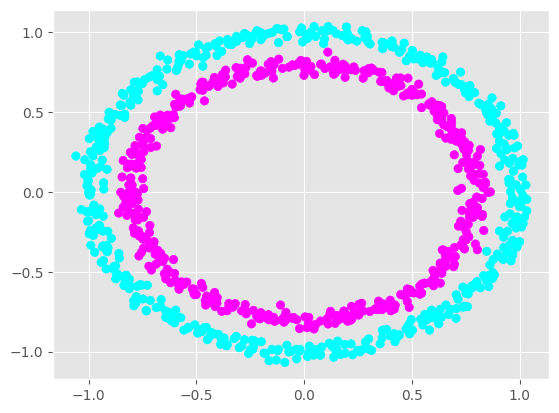

In [5]:
# Visualize DF
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="cool")

#### Input & Output Shapes

In [6]:
# Shapes of the feature and target

X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# Number of samples we're dealing with

len(X), len(y)

(1000, 1000)

In [8]:
# First data of each data
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

#### Data Splitting

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [10]:
# Train dataset shape
X_train.shape, y_train.shape

((700, 2), (700,))

In [11]:
# Test dataset shape
X_test.shape, y_test.shape

((300, 2), (300,))

#### Viusalize Train & Test Dataset

Text(0.5, 1.0, 'Visualize Train Dataset')

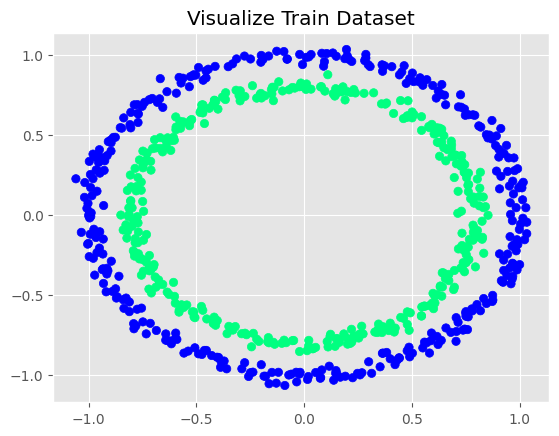

In [12]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="winter")
plt.title("Visualize Train Dataset")

Text(0.5, 1.0, 'Visualize Test Dataset')

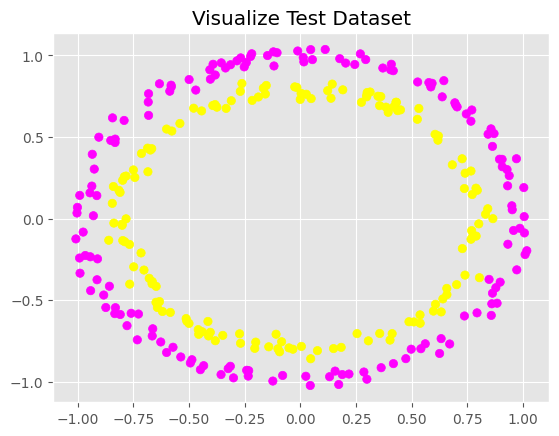

In [13]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="spring")
plt.title("Visualize Test Dataset")

#### Build a Model

In [14]:
import tensorflow as tf
from tensorflow import keras

In [24]:
tf.random.set_seed(42)

# Create Model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

# Compile model
model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss=tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])

# Train model
model_1.fit(X_train, y_train, epochs=200, verbose=2)


Epoch 1/200
22/22 - 1s - 62ms/step - accuracy: 0.5171 - loss: 2.1615
Epoch 2/200
22/22 - 0s - 4ms/step - accuracy: 0.5000 - loss: 0.7096
Epoch 3/200
22/22 - 0s - 5ms/step - accuracy: 0.4900 - loss: 0.6953
Epoch 4/200
22/22 - 0s - 4ms/step - accuracy: 0.4957 - loss: 0.6951
Epoch 5/200
22/22 - 0s - 5ms/step - accuracy: 0.5043 - loss: 0.6951
Epoch 6/200
22/22 - 0s - 4ms/step - accuracy: 0.4971 - loss: 0.6954
Epoch 7/200
22/22 - 0s - 3ms/step - accuracy: 0.4929 - loss: 0.6955
Epoch 8/200
22/22 - 0s - 6ms/step - accuracy: 0.4943 - loss: 0.6956
Epoch 9/200
22/22 - 0s - 4ms/step - accuracy: 0.4957 - loss: 0.6958
Epoch 10/200
22/22 - 0s - 3ms/step - accuracy: 0.4986 - loss: 0.6959
Epoch 11/200
22/22 - 0s - 3ms/step - accuracy: 0.4943 - loss: 0.6959
Epoch 12/200
22/22 - 0s - 3ms/step - accuracy: 0.4900 - loss: 0.6960
Epoch 13/200
22/22 - 0s - 3ms/step - accuracy: 0.4871 - loss: 0.6961
Epoch 14/200
22/22 - 0s - 3ms/step - accuracy: 0.4914 - loss: 0.6961
Epoch 15/200
22/22 - 0s - 4ms/step - accur

#### Improve The Model

In [41]:
tf.random.set_seed(42)


# Build Model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="sigmoid"),
    tf.keras.layers.Dense(1)
])


# Compile Model 
model_2.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                loss = tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])


# Training model
history2 = model_2.fit(X_train, y_train, epochs=250, verbose=2)


Epoch 1/250
22/22 - 1s - 36ms/step - accuracy: 0.4914 - loss: 1.0854
Epoch 2/250
22/22 - 0s - 3ms/step - accuracy: 0.4914 - loss: 0.7237
Epoch 3/250
22/22 - 0s - 3ms/step - accuracy: 0.4643 - loss: 0.7005
Epoch 4/250
22/22 - 0s - 3ms/step - accuracy: 0.4843 - loss: 0.6955
Epoch 5/250
22/22 - 0s - 3ms/step - accuracy: 0.5029 - loss: 0.6941
Epoch 6/250
22/22 - 0s - 3ms/step - accuracy: 0.5057 - loss: 0.6934
Epoch 7/250
22/22 - 0s - 3ms/step - accuracy: 0.5143 - loss: 0.6928
Epoch 8/250
22/22 - 0s - 3ms/step - accuracy: 0.5271 - loss: 0.6924
Epoch 9/250
22/22 - 0s - 3ms/step - accuracy: 0.5657 - loss: 0.6921
Epoch 10/250
22/22 - 0s - 5ms/step - accuracy: 0.5143 - loss: 0.6918
Epoch 11/250
22/22 - 0s - 3ms/step - accuracy: 0.5086 - loss: 0.6916
Epoch 12/250
22/22 - 0s - 3ms/step - accuracy: 0.5129 - loss: 0.6915
Epoch 13/250
22/22 - 0s - 3ms/step - accuracy: 0.5329 - loss: 0.6914
Epoch 14/250
22/22 - 0s - 3ms/step - accuracy: 0.5486 - loss: 0.6913
Epoch 15/250
22/22 - 0s - 3ms/step - accur

In [42]:
model2_eval = model_2.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9685 - loss: 0.3026  


Text(0.5, 0, 'epochs')

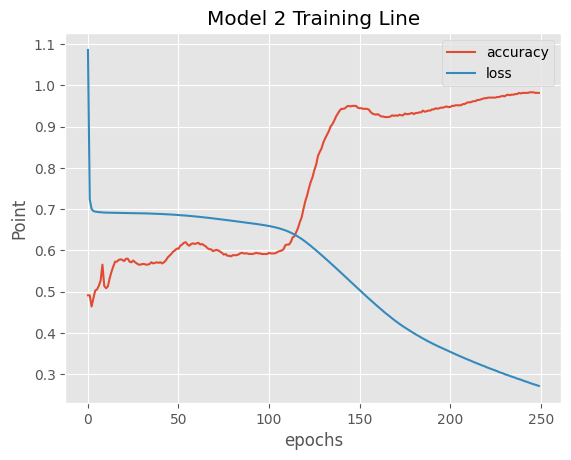

In [43]:
# Model 2 Training Visualize
pd.DataFrame(history2.history).plot()
plt.title("Model 2 Training Line")
plt.ylabel("Point")
plt.xlabel("epochs")

In [44]:
yPred_model2 = model_2.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [210]:
tf.random.set_seed(42)

# Build Model 3
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# Compile Model 3
model_3.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                loss = tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])


# Training Model 3

history3 = model_3.fit(X_train, y_train, epochs=200, verbose=2)

Epoch 1/200
22/22 - 1s - 52ms/step - accuracy: 0.5057 - loss: 0.6932
Epoch 2/200
22/22 - 0s - 3ms/step - accuracy: 0.5557 - loss: 0.6872
Epoch 3/200
22/22 - 0s - 3ms/step - accuracy: 0.5914 - loss: 0.6799
Epoch 4/200
22/22 - 0s - 3ms/step - accuracy: 0.6000 - loss: 0.6708
Epoch 5/200
22/22 - 0s - 3ms/step - accuracy: 0.6357 - loss: 0.6531
Epoch 6/200
22/22 - 0s - 4ms/step - accuracy: 0.6629 - loss: 0.6322
Epoch 7/200
22/22 - 0s - 3ms/step - accuracy: 0.6843 - loss: 0.6044
Epoch 8/200
22/22 - 0s - 3ms/step - accuracy: 0.7286 - loss: 0.5690
Epoch 9/200
22/22 - 0s - 3ms/step - accuracy: 0.7500 - loss: 0.5300
Epoch 10/200
22/22 - 0s - 3ms/step - accuracy: 0.8071 - loss: 0.4836
Epoch 11/200
22/22 - 0s - 3ms/step - accuracy: 0.8343 - loss: 0.4354
Epoch 12/200
22/22 - 0s - 4ms/step - accuracy: 0.8414 - loss: 0.3902
Epoch 13/200
22/22 - 0s - 4ms/step - accuracy: 0.8443 - loss: 0.3506
Epoch 14/200
22/22 - 0s - 4ms/step - accuracy: 0.9014 - loss: 0.3178
Epoch 15/200
22/22 - 0s - 3ms/step - accur

In [211]:
model3_eval = model_3.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0139  


Text(0.5, 0, 'epochs')

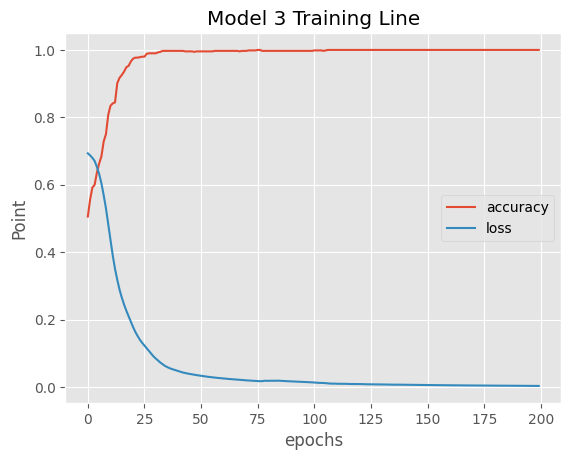

In [212]:
# Model 3 Training Visualize
pd.DataFrame(history3.history).plot()
plt.title("Model 3 Training Line")
plt.ylabel("Point")
plt.xlabel("epochs")

#### Model Prediction Visualization

plot_decision_boundary(), this function will:
- Take train model data (X and y)
- Create mashgrid of different X val
- Make prediction accross meshgrid
- Plot prediction

In [213]:
import numpy as np

def plot_decision_boundary(model, X, y):
    
    # Define axis boundaries of the plot and create meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X val (to make prediction data)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2d array together
    
    # Make predict
    y_pred = model.predict(x_in)
    
    # Check multiclass
    if len(y_pred[0]) > 1:
        print("Multiclass classification")
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
    
    # Plot
    plt.contourf(xx, yy, y_pred, cmap="seismic", alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=50, edgecolors="black")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step
Binary classification


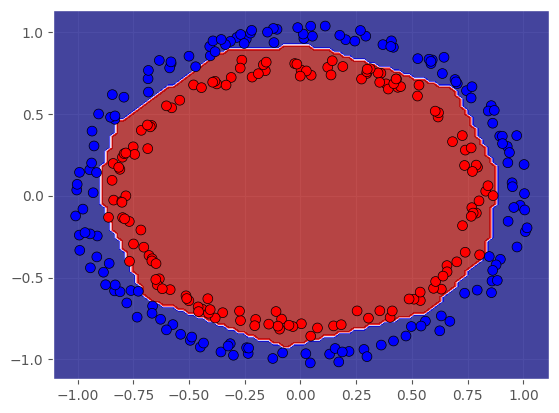

In [215]:
# Check prediction with best model 
plot_decision_boundary(model= model_3, X= X_test, y= y_test)